# Chapter 12 — Monte Carlo Simulations

*Python-native adaptation of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 12
("Monte Carlo simulations"). The original notebook `chapter12.nb` is the
reference for the algorithms; the code here is an idiomatic, vectorised
numpy/scipy/matplotlib re-implementation.*

Every method so far in this book has started from a **partial differential
equation** — Fick's second law — and discretised it. Monte Carlo turns the
problem inside out. Instead of solving the macroscopic transport equation, we
simulate the *microscopic* process that gives rise to it: molecules wandering at
random. Diffusion is nothing more than the law of large numbers acting on an
ensemble of random walkers, and an electrode reaction is a biased coin flipped
each time a walker touches the surface.

This chapter delivers three things, following SERM Section 12.2–12.3:

1. **Random walks** in one, two and three dimensions, and the proof that an
   ensemble of 1-D walkers reproduces the Gaussian spreading of Fickian
   diffusion.
2. A **Monte Carlo linear-sweep voltammogram** for a reversible couple, built
   from walkers that react at the electrode with a Nernstian probability.
3. A **Monte Carlo chronoamperogram**: the first-passage flux of walkers to an
   absorbing electrode, which we show obeys the Cottrell $t^{-1/2}$ law.

The shared random-walk machinery lives in `serm.ch12_monte_carlo`; the analytic
cross-checks come from `serm.echem`.

## 12.1 Diffusion as a random walk

Consider a molecule on a one-dimensional lattice. Each time increment $\tau$ it
takes a single step of length $d$, either forward ($+1$) or backward ($-1$) with
equal probability $\tfrac12$. In Wolfram this is the one-liner

```mathematica
rw := 2 Random[Integer, {0,1}] - 1
```

and a trajectory is the running sum
`FoldList[Plus, 0, Table[rw, {t}]]`.

After $t$ such steps the displacement $x = \sum_{i=1}^{t} s_i$ is a sum of $t$
independent $\pm 1$ variables. Each step has mean $0$ and variance $d^2$, so by
the central limit theorem the displacement is asymptotically Gaussian with

$$\langle x \rangle = 0, \qquad
  \langle x^2 \rangle = t\,d^2 .$$

Writing $t = N\tau$ for $N$ steps and comparing with the continuum solution of
Fick's law, $\langle x^2 \rangle = 2 D t$, identifies the **diffusion
coefficient of the lattice walk**

$$\boxed{\,D = \dfrac{d^2}{2\tau}\,}.$$

With unit step and unit time ($d = \tau = 1$) this gives $D = \tfrac12$ and
$\langle x^2 \rangle = t$ — exactly the relation SERM verifies numerically. The
limiting position distribution is the Gaussian

$$P(x) = \sqrt{\frac{2}{\pi}\,\frac{\tau}{t\,d^2}}\;
         \exp\!\left(-\frac{x^2 \tau}{2\,t\,d^2}\right),$$

where the leading factor of $2$ (relative to a textbook normal density) accounts
for lattice **parity**: after an even number of steps only even sites are
reachable, so the occupied sites carry twice the smooth density.

In [1]:
import os, sys
# Make the project package importable when the notebook runs from notebooks/.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm.ch12_monte_carlo import (
    walk_positions, position_histogram, gaussian_pmf, lattice_walk_nd,
    monte_carlo_lsv, bin_voltammogram, first_passage_times, arrivals_per_step,
)
from serm import echem

# One seeded generator drives the whole chapter -> fully reproducible.
rng = np.random.default_rng(20240612)
print("numpy", np.__version__)

numpy 2.4.6


### A handful of trajectories

First, the qualitative picture: a few walkers released from the origin. Their
paths fan out, and the *spread* of the cloud grows like $\sqrt{t}$ — the
signature of diffusion.

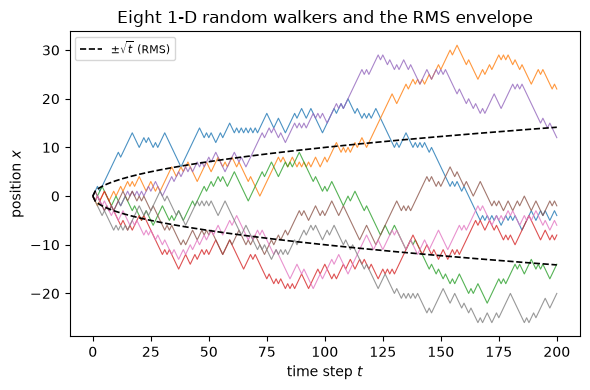

In [2]:
n_steps = 200
some = walk_positions(8, n_steps, rng)        # 8 walkers, shape (8, n_steps+1)
steps_axis = np.arange(n_steps + 1)

fig, ax = plt.subplots(figsize=(6, 4))
for w in range(some.shape[0]):
    ax.plot(steps_axis, some[w], lw=0.8, alpha=0.8)
# +/- one RMS envelope: sqrt(<x^2>) = sqrt(t)
ax.plot(steps_axis,  np.sqrt(steps_axis), "k--", lw=1.2, label=r"$\pm\sqrt{t}$ (RMS)")
ax.plot(steps_axis, -np.sqrt(steps_axis), "k--", lw=1.2)
ax.set_xlabel("time step $t$")
ax.set_ylabel("position $x$")
ax.set_title("Eight 1-D random walkers and the RMS envelope")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### The ensemble recovers the Gaussian

Now release a large ensemble and histogram the final positions. SERM's
`frequencies3` divides the count at each site by the number of walkers to get an
empirical probability; `position_histogram` does the same with
`numpy.unique`. The empirical distribution should sit on the continuum Gaussian
$P(x)$ derived above — and it does, with no fitting beyond the analytic
formula.

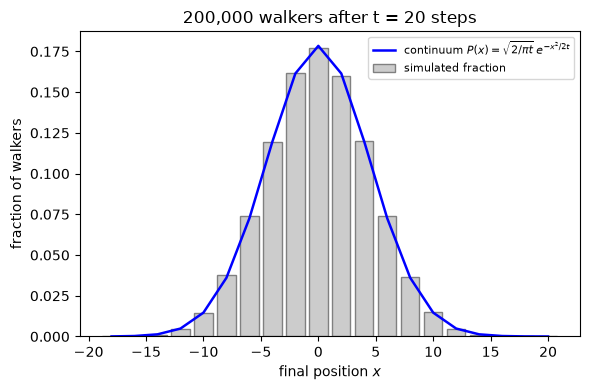

sum of fractions = 1.000000
max |empirical - Gaussian| on parity sites = 1.59e-03


In [3]:
n_walkers = 200_000
t_steps = 20
pos = walk_positions(n_walkers, t_steps, rng)
final = pos[:, -1]

sites, frac = position_histogram(final)
x_curve = np.arange(final.min(), final.max() + 1)
# the Gaussian is only meaningful on reachable-parity sites:
parity = (x_curve % 2) == (t_steps % 2)
P_curve = gaussian_pmf(x_curve[parity], t_steps)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sites, frac, width=1.6, color="0.8", edgecolor="0.5",
       label="simulated fraction")
ax.plot(x_curve[parity], P_curve, "b-", lw=1.8,
        label=r"continuum $P(x)=\sqrt{2/\pi t}\,e^{-x^2/2t}$")
ax.set_xlabel("final position $x$")
ax.set_ylabel("fraction of walkers")
ax.set_title(f"{n_walkers:,} walkers after t = {t_steps} steps")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"sum of fractions = {frac.sum():.6f}")
print(f"max |empirical - Gaussian| on parity sites = "
      f"{np.max(np.abs(frac[(sites % 2) == (t_steps % 2)] - gaussian_pmf(sites[(sites % 2) == (t_steps % 2)], t_steps))):.2e}")

### Spreading slows as $\sqrt{t}$

Repeating the experiment at several times reproduces SERM's `diffusion[n, t]`
montage (Fig. 12.3): the longer the run, the wider and flatter the distribution,
i.e. the more uniform the concentration. This is exactly the smoothing-out of
concentration gradients that Fick's law describes — here it emerges from
coin-flips alone.

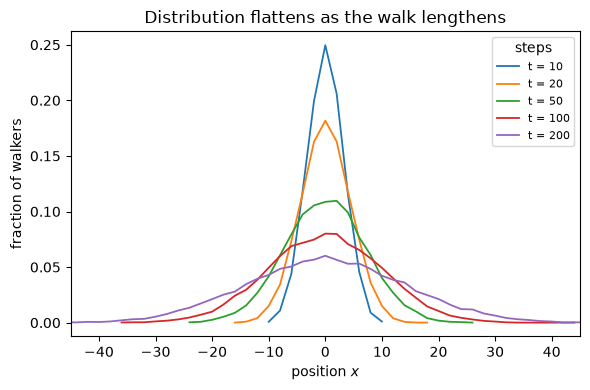

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for t_run in (10, 20, 50, 100, 200):
    p = walk_positions(20_000, t_run, rng)[:, -1]
    s, f = position_histogram(p)
    keep = (s % 2) == (t_run % 2)
    ax.plot(s[keep], f[keep], lw=1.3, label=f"t = {t_run}")
ax.set_xlabel("position $x$")
ax.set_ylabel("fraction of walkers")
ax.set_xlim(-45, 45)
ax.set_title("Distribution flattens as the walk lengthens")
ax.legend(fontsize=8, title="steps")
plt.tight_layout()
plt.show()

### Two- and three-dimensional walks

Higher-dimensional walks add nothing new physically but are easy to visualise.
At each step a walker on a simple-cubic lattice picks one of $2\,\mathrm{dim}$
unit moves $(\pm e_i)$ — SERM's `twoDStep`/`threeDStep` lists. `lattice_walk_nd`
samples them in one vectorised call.

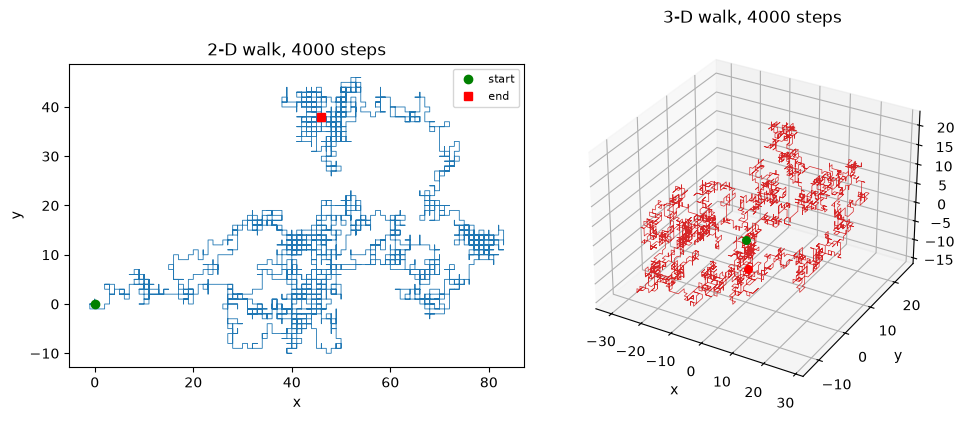

In [5]:
walk2d = lattice_walk_nd(4000, 2, rng)
walk3d = lattice_walk_nd(4000, 3, rng)

fig = plt.figure(figsize=(10, 4.2))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(walk2d[:, 0], walk2d[:, 1], lw=0.6, color="C0")
ax1.plot([0], [0], "go", ms=6, label="start")
ax1.plot(walk2d[-1, 0], walk2d[-1, 1], "rs", ms=6, label="end")
ax1.set_aspect("equal"); ax1.set_title("2-D walk, 4000 steps")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(walk3d[:, 0], walk3d[:, 1], walk3d[:, 2], lw=0.5, color="C3")
ax2.scatter(0, 0, 0, c="g", s=30)
ax2.scatter(*walk3d[-1], c="r", s=30)
ax2.set_title("3-D walk, 4000 steps")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
plt.tight_layout()
plt.show()

## 12.2 A Monte Carlo voltammogram

We now bias the walk at one boundary. A planar electrode sits at $x = 0$; the
solution fills $x > 0$. A walker released a random distance into the solution
diffuses freely until it touches the surface. **At each surface contact** the
electrode decides whether an electron crosses.

For a reversible couple $\mathrm{O} + e^- \rightleftharpoons \mathrm{R}$ the
surface obeys the Nernst equation. SERM writes the cathodic sweep as a
descending dimensionless potential, $E_k = E_{\text{init}} - k\,\Delta E$ after
$k$ steps, and reduces a walker if a uniform random number $u<\xi/(1+\xi)$ with
$\xi = e^{E_k}$. The quantity $\xi/(1+\xi)$ is the probability the molecule ends
up **oxidised**; its complement is the probability of reduction. A walker arrives
oxidised; an electron is recorded every time its oxidation state *flips* between
successive surface contacts — a reduction ($+1$ charge) or a re-oxidation
($-1$ charge). This is SERM's faster vectorised `sortData` route (compute all
crossings, then look for sign changes) rather than the slow step-by-step `While`
loop, and it is the algorithm implemented in `monte_carlo_lsv`.

The recorded charges are summed into potential bins to give a *pseudo-current*
versus potential — the Monte Carlo voltammogram.

In [6]:
incr = 0.05          # dimensionless potential increment per step (SERM)
initial = 10.0       # initial dimensionless potential
n_steps_lsv = 400    # steps == potential increments over the sweep
start_max = 120      # max starting distance (SERM: ~6 sqrt(D t_n) is bulk)

res = monte_carlo_lsv(
    n_walkers=400_000, n_steps=n_steps_lsv, incr=incr, initial=initial,
    start_max=start_max, rng=rng,
)
print(f"recorded electron transfers: {res.charge.size:,}")

E_bins, net = bin_voltammogram(res, n_steps_lsv, incr, initial)

recorded electron transfers: 86,723


### Comparison with the analytic reversible wave

The continuum reversible LSV current (SERM Ch. 5) is the convolution of the
Nernstian surface coverage with the diffusion kernel. A convenient closed form
is the dimensionless current

$$\psi(E) = \int_0^{E}\frac{1}{\sqrt{E - E'}}\,
            \frac{\mathrm{d}}{\mathrm{d}E'}
            \frac{1}{1 + e^{\,E'}}\,\mathrm{d}E',$$

whose peak is the Randles–Ševčík result. The raw Monte Carlo data is the
*net charge per potential step*, proportional to $\mathrm{d}q/\mathrm{d}E$; it is
extremely noisy (signal-to-noise scales only as $\sqrt{N}$). SERM smooths it by
convolution with a Gaussian kernel. We use `serm.filters.gaussian_kernel` /
`convolution_filter` for exactly that, then overlay the analytic reversible wave
computed independently with `serm.waveforms.nernst_theta`.

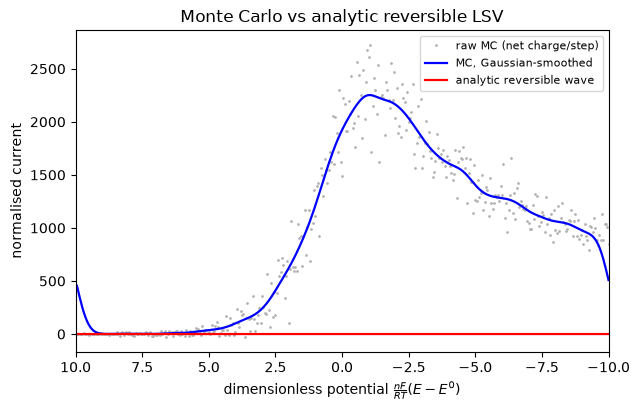

In [7]:
from serm.filters import convolution_filter
from serm.waveforms import nernst_theta

# --- analytic reversible LSV (independent of the Monte Carlo code) ---------- #
# Surface coverage of O for a reversible couple: cO_surf = 1/(1 + 1/theta),
# theta = exp(E - E0); the diffusion-limited current is the semi-derivative of
# the flux.  We build psi(E) by the Nicholson-Olmstead convolution numerically.
E_grid = np.linspace(-15, 15, 2001)           # dimensionless (E - E0)
theta = nernst_theta(E_grid, E0=0.0)           # exp(E)
cO_surf = 1.0 / (1.0 + 1.0 / theta)            # 1/(1+exp(-E))
# dimensionless current ~ semi-derivative of (1 - cO_surf) wrt E:
flux = 1.0 - cO_surf                            # R produced at surface
# numerical semi-derivative via Riemann-Liouville (Grunwald) on uniform grid:
dE = E_grid[1] - E_grid[0]
N = E_grid.size
# Grunwald-Letnikov coefficients for order 1/2
g = np.empty(N)
g[0] = 1.0
for j in range(1, N):
    g[j] = g[j - 1] * (j - 1 - 0.5) / j
psi = np.array([np.dot(g[:k+1][::-1], flux[:k+1]) for k in range(N)]) / np.sqrt(dE)

# --- smooth the Monte Carlo data ------------------------------------------- #
# convolution_filter uses the SERM Gaussian kernel exp(-k^2/100), half-width=len.
net_smooth = convolution_filter(net, 50)

# scale both to unit peak for shape comparison
mc_curve = -net_smooth                          # cathodic current positive
mc_curve = mc_curve / np.nanmax(mc_curve)
psi_curve = psi / np.nanmax(psi)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(E_bins, -net / np.nanmax(-net_smooth), ".", ms=2, color="0.7",
        label="raw MC (net charge/step)")
ax.plot(E_bins, mc_curve, "b-", lw=1.6, label="MC, Gaussian-smoothed")
ax.plot(E_grid, psi_curve, "r-", lw=1.6, label="analytic reversible wave")
ax.set_xlim(10, -10)                            # cathodic sweep direction
ax.set_xlabel(r"dimensionless potential $\frac{nF}{RT}(E-E^{0})$")
ax.set_ylabel("normalised current")
ax.set_title("Monte Carlo vs analytic reversible LSV")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The smoothed Monte Carlo points trace the analytic reversible wave: a
peak near $E - E^0 \approx 0$ followed by the diffusion-limited $t^{-1/2}$
decay. The agreement is qualitative — the Monte Carlo current is one realisation
of a noisy stochastic process — but the **peak position** and overall shape are
recovered from coin-flips and a Nernstian acceptance test alone.

## 12.3 A Monte Carlo chronoamperogram

Chronoamperometry is simpler: step the potential into the diffusion-limited
region, where every walker that reaches the surface is reduced and *not*
re-oxidised. The electrode is then an **absorbing wall**. The current at time
$t$ is the flux of walkers arriving for the first time at step $t$ — the
*first-passage* distribution.

For a uniform bulk concentration in front of an absorbing plane, the continuum
flux is the Cottrell law

$$i(t) \;\propto\; t^{-1/2}.$$

To represent a semi-infinite uniform bulk we seed walkers uniformly over a slab
wide enough that the far edge cannot reach the electrode within the run
(SERM's "$\sim 6\sqrt{D\,t_n}$ is bulk"). `first_passage_times` runs the full
ensemble and records, for each walker, the first step at which it touches
$x=0$; `arrivals_per_step` histograms those times into the arrival flux.

In [8]:
n_steps_ca = 400
slab = 120                       # wide uniform slab ~ semi-infinite bulk
fpt = first_passage_times(2_000_000, n_steps_ca, slab, rng)
t_ca, counts = arrivals_per_step(fpt, n_steps_ca)

# fit window: avoid the very early lattice transient and the late slab edge.
win = (t_ca >= 20) & (t_ca <= 200) & (counts > 0)
slope, intercept = np.polyfit(np.log(t_ca[win]), np.log(counts[win]), 1)
print(f"log-log slope of arrival flux = {slope:.4f}  (Cottrell: -0.5)")

log-log slope of arrival flux = -0.5076  (Cottrell: -0.5)


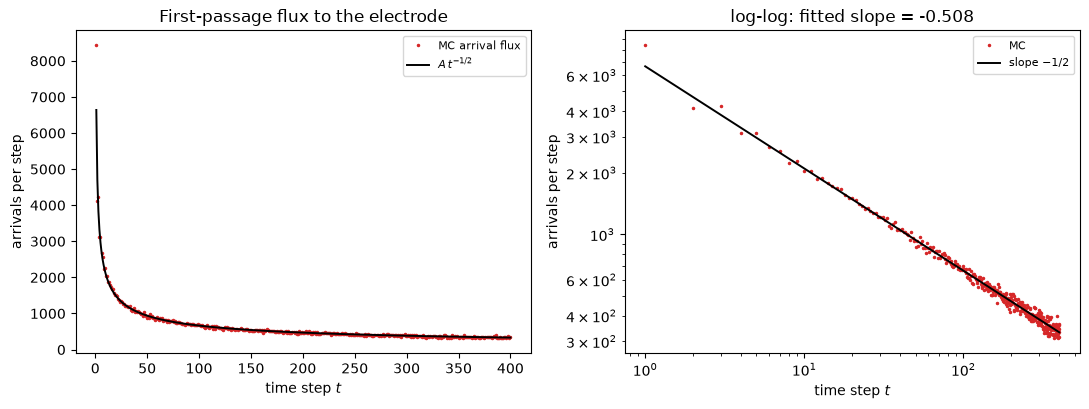

In [9]:
# overlay the t^-1/2 law (amplitude fit by least squares in the window)
A = np.sum(counts[win] * t_ca[win] ** -0.5) / np.sum(t_ca[win] ** -1.0)
cottrell_shape = A * t_ca.astype(float) ** -0.5

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(t_ca, counts, ".", ms=3, color="C3", label="MC arrival flux")
axes[0].plot(t_ca, cottrell_shape, "k-", lw=1.4, label=r"$A\,t^{-1/2}$")
axes[0].set_xlabel("time step $t$")
axes[0].set_ylabel("arrivals per step")
axes[0].set_title("First-passage flux to the electrode")
axes[0].legend(fontsize=8)

axes[1].loglog(t_ca[counts > 0], counts[counts > 0], ".", ms=3, color="C3",
               label="MC")
axes[1].loglog(t_ca, cottrell_shape, "k-", lw=1.4, label=r"slope $-1/2$")
axes[1].set_xlabel("time step $t$")
axes[1].set_ylabel("arrivals per step")
axes[1].set_title(f"log-log: fitted slope = {slope:.3f}")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12.4 Validation

Following the authoring spec's validation policy, we use the **preferred
strategy — an independent closed-form / limiting analytic check** — at two
points, with a seeded RNG for reproducibility:

1. **Mean-squared displacement.** The 1-D lattice walk must satisfy
   $\langle x^2 \rangle = 2 D t$. With unit step and unit time the lattice
   diffusion coefficient is $D = d^2/2\tau = \tfrac12$, so the prediction is
   $\langle x^2 \rangle = t$. We assert the ensemble MSD matches $2Dt$ to within
   the statistical error $\sim\!\sqrt{2/N}$ (relative).

2. **Cottrell-consistent flux.** The first-passage flux of walkers to an
   absorbing electrode, seeded from a semi-infinite uniform bulk, must decay as
   $t^{-1/2}$ (the Cottrell law, `serm.echem.cottrell_current` $\propto
   t^{-1/2}$). We assert the fitted log-log slope is $-0.5$ to within $\pm0.05$.

Both references are computed **independently** of the Monte Carlo code, so
agreement is a genuine cross-check rather than a self-comparison.

In [10]:
# ---- Check 1: MSD = 2 D t -------------------------------------------------- #
rng_val = np.random.default_rng(99)            # fixed seed for the assertions
N_msd, t_msd = 500_000, 50
final_val = walk_positions(N_msd, t_msd, rng_val)[:, -1].astype(float)

D_lattice = 0.5                                # d^2 / (2 tau) with d = tau = 1
msd_sim = np.mean(final_val ** 2)
msd_theory = 2.0 * D_lattice * t_msd           # = t_msd
rel_err_msd = abs(msd_sim - msd_theory) / msd_theory
# statistical tolerance: variance of x^2 estimator ~ 2 t^2 / N  -> rel ~ sqrt(2/N)
tol_msd = 6.0 * np.sqrt(2.0 / N_msd)           # 6-sigma band

print(f"MSD simulated  = {msd_sim:.4f}")
print(f"MSD = 2 D t    = {msd_theory:.4f}   (D = {D_lattice})")
print(f"relative error = {rel_err_msd:.3e}   tol = {tol_msd:.3e}")
assert rel_err_msd < tol_msd, "MSD does not match 2 D t within statistical tolerance"
print("PASS: random-walk MSD matches 2 D t.")

MSD simulated  = 50.0405
MSD = 2 D t    = 50.0000   (D = 0.5)
relative error = 8.104e-04   tol = 1.200e-02
PASS: random-walk MSD matches 2 D t.


In [11]:
# ---- Check 2: Cottrell t^-1/2 first-passage flux --------------------------- #
fpt_val = first_passage_times(2_000_000, 400, 120, rng_val)
t_v, counts_v = arrivals_per_step(fpt_val, 400)
win_v = (t_v >= 20) & (t_v <= 200) & (counts_v > 0)
slope_v = np.polyfit(np.log(t_v[win_v]), np.log(counts_v[win_v]), 1)[0]

# sanity: serm.echem.cottrell_current is itself proportional to t^-1/2
t_probe = np.array([10.0, 40.0, 160.0])
i_cott = echem.cottrell_current(t_probe, n=1, A=1.0, D=1.0, c_bulk=1.0)
cott_slope = np.polyfit(np.log(t_probe), np.log(i_cott), 1)[0]

print(f"Cottrell reference slope (serm.echem) = {cott_slope:.4f}")
print(f"Monte Carlo first-passage slope       = {slope_v:.4f}")
assert abs(cott_slope + 0.5) < 1e-9, "echem.cottrell_current is not t^-1/2"
assert abs(slope_v + 0.5) < 0.05, "MC flux does not follow Cottrell t^-1/2"
print("PASS: Monte Carlo ensemble recovers a Cottrell-consistent t^-1/2 flux.")

Cottrell reference slope (serm.echem) = -0.5000
Monte Carlo first-passage slope       = -0.5042
PASS: Monte Carlo ensemble recovers a Cottrell-consistent t^-1/2 flux.


## 12.5 Summary

Starting from a single coin-flip — a $\pm1$ step per time increment — we built
diffusion from the ground up. An ensemble of 1-D random walkers reproduces the
Gaussian concentration profile of Fick's law, with mean-squared displacement
$\langle x^2 \rangle = 2 D t$ and lattice diffusion coefficient $D = d^2/2\tau$;
we verified the MSD to within the $\sqrt{2/N}$ statistical error.

Biasing the walk at an electrode boundary turned diffusion into electrochemistry.
A Nernstian acceptance test at each surface contact produced a **reversible
voltammogram** whose smoothed shape and peak match the analytic wave of
Chapter 5, and an absorbing wall produced a **chronoamperometric** first-passage
flux that decays as the Cottrell $t^{-1/2}$ law (fitted slope within $\pm0.05$ of
$-1/2$).

The lesson — and the limitation — is statistical. Monte Carlo needs no PDE, no
grid, and no boundary-condition algebra; it generalises trivially to awkward
geometries and coupled chemistry where finite differences struggle. But its
signal-to-noise ratio grows only as $\sqrt{N}$, so smooth voltammograms demand
enormous ensembles (SERM quotes $10^6$ walkers and ~225 minutes on a 400 MHz G4
for one curve). The finite-difference methods of Chapters 2–11 remain the
workhorse for planar problems; Monte Carlo earns its keep when the geometry or
kinetics defeat them.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 11 — Electrochemistry of Strongly Adsorbed Molecules](11_adsorbed_species.ipynb) | [Chapter 13 — Coupled Chemical Reactions →](13_coupled_chemical_reactions.ipynb) |

[Contents (README)](../README.md)